In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, precision_score, recall_score,f1_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv("Telco_Customer_Churn.csv")

In [4]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [5]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [6]:
df["TotalCharges"].nunique()

6531

In [7]:
df["TotalCharges"].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.9       8
20.05      8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
6844.5     1
Name: count, Length: 6531, dtype: int64

In [8]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [10]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [11]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
df.dropna(subset=["TotalCharges"], inplace=True)

In [13]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [14]:
df.shape

(7032, 21)

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [17]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [18]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

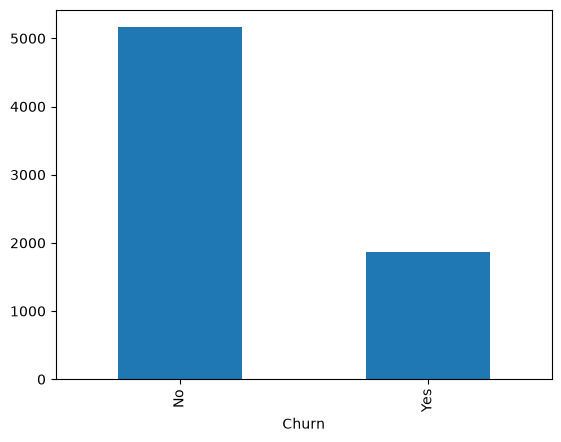

In [19]:
df["Churn"].value_counts().plot(kind="bar")

In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
# Observation 
## 1. The average customer tenure is approximately 32 months.
## 2. Only 16% of the customers are senior citizens.
## 3. Monthly charges range from 18 to 118.
## 4. Some customers are very new (tenure = 0), while some have been with the company for up to 72 months.
## 5. Further analysis is required to determine whether tenure and monthly charges influence customer churn.

In [22]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

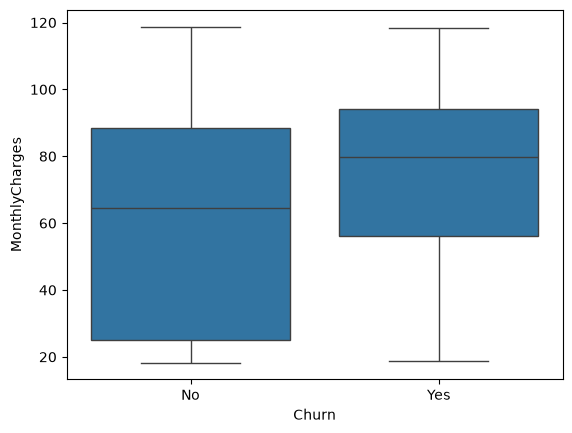

In [23]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

In [24]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

<Axes: xlabel='Churn', ylabel='tenure'>

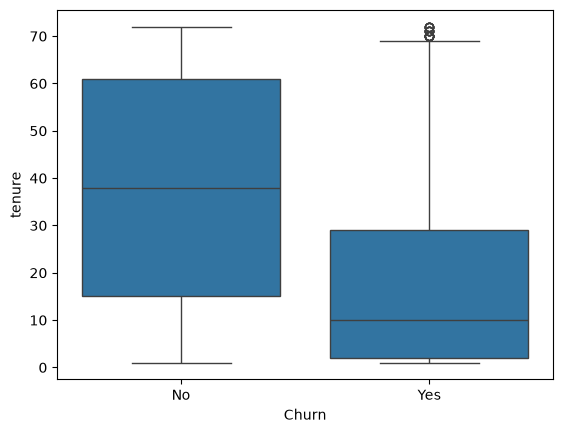

In [25]:
sns.boxplot(data=df, x="Churn", y="tenure")

In [26]:
df.groupby("Churn")["Contract"].value_counts()

Churn  Contract      
No     Month-to-month    2220
       Two year          1637
       One year          1306
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

In [27]:
df.select_dtypes(include='object').columns

C:\Users\Neha\AppData\Local\Temp\ipykernel_16248\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [28]:
df.describe(include="object")

C:\Users\Neha\AppData\Local\Temp\ipykernel_16248\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


In [29]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

In [30]:
df.groupby("Churn")["SeniorCitizen"].value_counts()

Churn  SeniorCitizen
No     0                4497
       1                 666
Yes    0                1393
       1                 476
Name: count, dtype: int64

In [31]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [32]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [33]:
df.groupby("Churn")["InternetService"].value_counts()

Churn  InternetService
No     DSL                1957
       Fiber optic        1799
       No                 1407
Yes    Fiber optic        1297
       DSL                 459
       No                  113
Name: count, dtype: int64

In [34]:
pd.crosstab(df["InternetService"],df["Churn"], normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [35]:
df.drop("customerID", axis=1, inplace=True)

In [36]:
df.select_dtypes(include='object').columns

C:\Users\Neha\AppData\Local\Temp\ipykernel_16248\3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [37]:
for col in ["MultipleLines", "InternetService", "Contract", "PaymentMethod"]:
    print(col)
    print(df[col].unique())
    print("-"*40)

MultipleLines
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------------------------------------
InternetService
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
----------------------------------------
Contract
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
----------------------------------------
PaymentMethod
<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str
----------------------------------------


In [38]:
binary_cols = ["gender", "Partner", "Dependents","PhoneService", "PaperlessBilling", "Churn"]

In [39]:
for col in binary_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------
Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
PhoneService
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
PaperlessBilling
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
Churn
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------


In [40]:
df["gender"] = df["gender"].map({"Male":1, "Female":0})
df["Dependents"] = df["Dependents"].map({"Yes":1, "No":0})
df["Partner"] = df["Partner"].map({"Yes": 1, "No" : 0})
df["PhoneService"] = df["PhoneService"].map({"Yes": 1, "No": 0})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes": 1, "No": 0})
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [41]:
internet_cols = ["OnlineSecurity", "OnlineBackup","DeviceProtection", "TechSupport","StreamingTV", "StreamingMovies"]

In [42]:
for col in internet_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

OnlineSecurity
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
OnlineBackup
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
----------------------------------------
DeviceProtection
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
TechSupport
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
StreamingTV
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
StreamingMovies
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------


In [43]:
for col in internet_cols:
    df[col] = df[col].replace("No internet service", "No")

In [44]:
for col in internet_cols:
    df[col] = df[col].map({"Yes":1, "No":0})

In [45]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service","No")
df["MultipleLines"] = df["MultipleLines"].map({"Yes":1,"No":0})

In [46]:
ohe_cols = ["InternetService", "Contract", "PaymentMethod"]
df = pd.get_dummies(df,
                    columns=ohe_cols,
                    drop_first=True)

In [47]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   MultipleLines                          7032 non-null   int64  
 7   OnlineSecurity                         7032 non-null   int64  
 8   OnlineBackup                           7032 non-null   int64  
 9   DeviceProtection                       7032 non-null   int64  
 10  TechSupport                            7032 non-null   int64  
 11  StreamingTV         

In [48]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [49]:
df.shape

(7032, 24)

In [50]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
scaler = StandardScaler()

In [53]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [177]:
model = LogisticRegression()

In [55]:
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [56]:
y_pred = model.predict(X_test_scaled)

In [57]:
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)
print("Training Accuracy :", train_score)
print("Testing Accuracy :", test_score)

Training Accuracy : 0.8039111111111111
Testing Accuracy : 0.8038379530916845


In [58]:
y_pred = model.predict(X_test_scaled)

In [59]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8038379530916845
Precision : 0.6475903614457831
Recall : 0.5748663101604278
F1 Score : 0.6090651558073654
[[916 117]
 [159 215]]


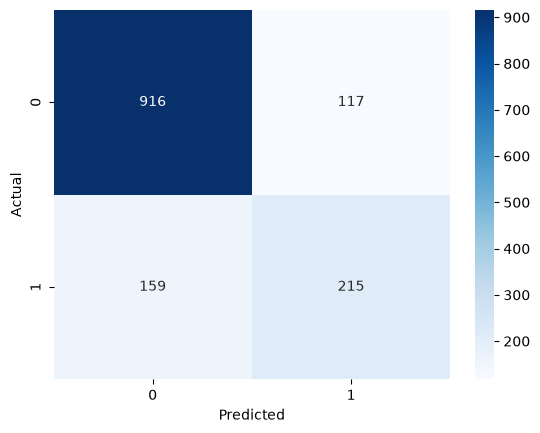

In [60]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [116]:
rf_baseline = RandomForestClassifier(random_state=42)

rf_baseline.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [118]:
y_pred_baseline = rf_baseline.predict(X_test)

In [119]:
train_acc_baseline = rf_baseline.score(X_train, y_train)
test_acc_baseline = rf_baseline.score(X_test, y_test)

print("Training Accuracy :", train_acc_baseline)
print("Testing Accuracy :", test_acc_baseline)

Training Accuracy : 0.9987555555555555
Testing Accuracy : 0.7910447761194029


In [120]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_baseline))
print("Precision :", precision_score(y_test, y_pred_baseline))
print("Recall :", recall_score(y_test, y_pred_baseline))
print("F1 Score :", f1_score(y_test, y_pred_baseline))

Accuracy : 0.7910447761194029
Precision : 0.6324503311258278
Recall : 0.5106951871657754
F1 Score : 0.5650887573964497


In [121]:
print(confusion_matrix(y_test, y_pred_baseline))

[[922 111]
 [183 191]]


In [122]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [132]:
### Observation

# - Training Accuracy = 99.8%
# - Testing Accuracy = 79.1%

# The model achieved extremely high training accuracy but significantly lower testing accuracy, indicating overfitting.

# Precision = xx%

# Recall = xx%

# The model failed to generalize well on unseen data.

# Next Step:
# Tune the Random Forest hyperparameters to reduce overfitting.

### Conclusion:
## The baseline Random Forest severely overfit the training data. Therefore, the next experiment focuses on reducing the model complexity using the `max_depth` parameter.

In [124]:
rf_depth6 = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

In [125]:
rf_depth6.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [130]:
y_pred_depth6 = rf_depth6.predict(X_test)

In [126]:
train_acc_depth6 = rf_depth6.score(X_train, y_train)
test_acc_depth6 = rf_depth6.score(X_test, y_test)
print("Training Accuracy :", train_acc_depth6)
print("Testing Accuracy :", test_acc_depth6)

Training Accuracy : 0.8097777777777778
Testing Accuracy : 0.7882018479033405


In [131]:
print("Accuracy :", accuracy_score(y_test, y_pred_depth6))
print("Precision :", precision_score(y_test, y_pred_depth6))
print("Recall :", recall_score(y_test, y_pred_depth6))
print("F1 Score :", f1_score(y_test, y_pred_depth6))
print(confusion_matrix(y_test, y_pred_depth6))

Accuracy : 0.7882018479033405
Precision : 0.6570247933884298
Recall : 0.42513368983957217
F1 Score : 0.5162337662337663
[[950  83]
 [215 159]]


In [ ]:
### Observation

## - Training Accuracy decreased from 99% to 80%.
## - Testing Accuracy remained approximately the same.
## - Overfitting was reduced after limiting the tree depth.
## - However, Recall decreased, indicating that the model identified fewer churn customers.
## - This suggests a bias-variance trade-off: reducing model complexity improved generalization but also reduced the model's ability to detect the minority class.

## Conclusion:
## Reducing `max_depth` successfully controlled overfitting, but at the cost of lower Recall. 
## Therefore, this configuration was not selected as the final model.

In [134]:
rf_balanced = RandomForestClassifier(
    class_weight="balanced",
    random_state=42)

In [135]:
rf_balanced.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [136]:
y_pred_balanced = rf_balanced.predict(X_test)

In [137]:
train_acc_balanced = rf_balanced.score(X_train, y_train)
test_acc_balanced = rf_balanced.score(X_test, y_test)

print("Training Accuracy :", train_acc_balanced)
print("Testing Accuracy :", test_acc_balanced)

Training Accuracy : 0.9937777777777778
Testing Accuracy : 0.7611940298507462


In [139]:
print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision :", precision_score(y_test, y_pred_balanced))
print("Recall :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))
print(confusion_matrix(y_test, y_pred_balanced))

Accuracy : 0.7611940298507462
Precision : 0.5422222222222223
Recall : 0.6524064171122995
F1 Score : 0.5922330097087378
[[827 206]
 [130 244]]


In [140]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [141]:
### Observation

## - Training Accuracy remained high.
## - Testing Accuracy showed no significant improvement.
## - Precision, Recall and F1-score remained almost unchanged.
## - Assigning balanced class weights did not significantly improve the model's ability to detect churn customers.

### Conclusion:

## For this dataset, using `class_weight='balanced'` alone was not sufficient to improve minority class prediction. Therefore, the next logical step is to explore resampling techniques such as SMOTE.

In [144]:
comparison = {
    "Model": [
        "Random Forest (Baseline)",
        "Random Forest (max_depth=6)",
        "Random Forest (class_weight='balanced')"
    ],

    "Train Accuracy": [
        train_acc_baseline,
        train_acc_depth6,
        train_acc_balanced
    ],

    "Test Accuracy": [
        test_acc_baseline,
        test_acc_depth6,
        test_acc_balanced
    ],

    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_depth6),
        precision_score(y_test, y_pred_balanced)
    ],

    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_depth6),
        recall_score(y_test, y_pred_balanced)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_depth6),
        f1_score(y_test, y_pred_balanced)
    ]
}

comparison_df = pd.DataFrame(comparison)

In [145]:
comparison_df = comparison_df.round(3)

comparison_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Random Forest (Baseline),0.999,0.791,0.632,0.511,0.565
1,Random Forest (max_depth=6),0.810,0.788,0.657,0.425,0.516
2,Random Forest (class_weight='balanced'),0.994,0.761,0.542,0.652,0.592


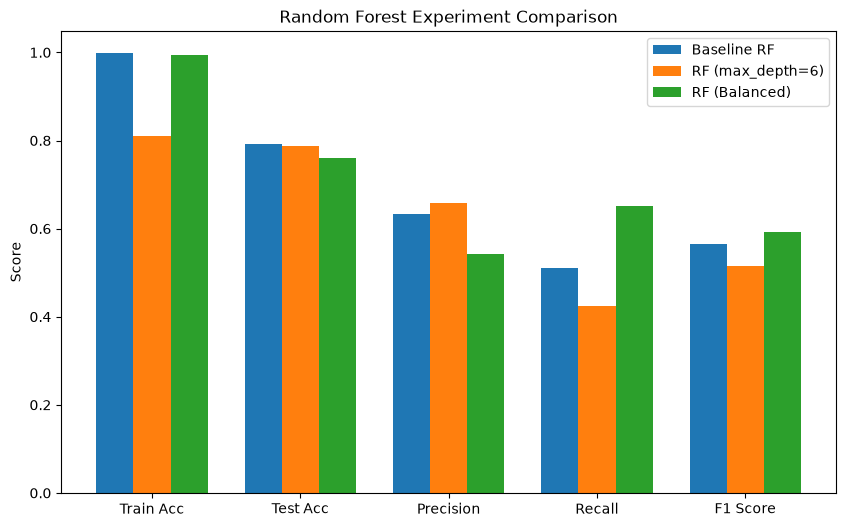

In [146]:
metrics = ["Train Acc", "Test Acc", "Precision", "Recall", "F1 Score"]

baseline = [
    train_acc_baseline,
    test_acc_baseline,
    precision_score(y_test, y_pred_baseline),
    recall_score(y_test, y_pred_baseline),
    f1_score(y_test, y_pred_baseline)
]

depth6 = [
    train_acc_depth6,
    test_acc_depth6,
    precision_score(y_test, y_pred_depth6),
    recall_score(y_test, y_pred_depth6),
    f1_score(y_test, y_pred_depth6)
]

balanced = [
    train_acc_balanced,
    test_acc_balanced,
    precision_score(y_test, y_pred_balanced),
    recall_score(y_test, y_pred_balanced),
    f1_score(y_test, y_pred_balanced)
]

x = range(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar([i-width for i in x], baseline, width=width, label="Baseline RF")
plt.bar(x, depth6, width=width, label="RF (max_depth=6)")
plt.bar([i+width for i in x], balanced, width=width, label="RF (Balanced)")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Random Forest Experiment Comparison")
plt.legend()

plt.show()

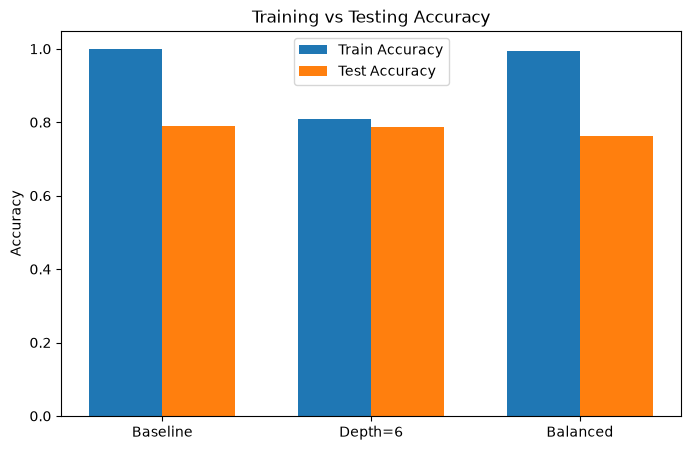

In [147]:
models = [
    "Baseline",
    "Depth=6",
    "Balanced"
]

train = [
    train_acc_baseline,
    train_acc_depth6,
    train_acc_balanced
]

test = [
    test_acc_baseline,
    test_acc_depth6,
    test_acc_balanced
]

x = range(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar([i-width/2 for i in x], train, width=width, label="Train Accuracy")
plt.bar([i+width/2 for i in x], test, width=width, label="Test Accuracy")

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy")
plt.legend()

plt.show()

In [166]:
smote = SMOTE(random_state=42)

In [167]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [168]:
print("Before SMOTE")
print(y_train.value_counts())

print("-"*40)

print("After SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Churn
0    4130
1    1495
Name: count, dtype: int64
----------------------------------------
After SMOTE
Churn
0    4130
1    4130
Name: count, dtype: int64


In [169]:
scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [170]:
lr_smote = LogisticRegression(random_state=42)

lr_smote.fit(X_train_smote_scaled, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [171]:
y_pred_smote = lr_smote.predict(X_test_scaled)

In [174]:
print("Accuracy :", accuracy_score(y_test, y_pred_smote))
print("Precision :", precision_score(y_test, y_pred_smote))
print("Recall :", recall_score(y_test, y_pred_smote))
print("F1 Score :", f1_score(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

Accuracy : 0.7633262260127932
Precision : 0.5473441108545035
Recall : 0.6336898395721925
F1 Score : 0.587360594795539
[[837 196]
 [137 237]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.63      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.78      0.76      0.77      1407

